# Modelos de regressão

<hr>

https://www.youtube.com/watch?v=7ArmBVF2dCs "Linear Regression, Clearly Explained" - StatsQuest

https://www.youtube.com/watch?v=bMccdk8EdGo  "R-Squared, Clearly Explained" - StatsQuest


Resumo dos Conceitos

Os modelos de regressão buscam entender e quantificar a relação entre uma variável resposta (dependente, `Y`) e uma ou mais variáveis preditoras (independentes, `X`).

O principal objetivo é:

- explicar relações entre variáveis
- realizar previsões
- medir impacto de variáveis sobre um resultado

**Método dos Mínimos Quadrados (MMQ)**

O Método dos Mínimos Quadrados (*Ordinary Least Squares — OLS*) é a técnica mais utilizada para ajustar a "reta que melhor representa os dados".

A ideia central é minimizar os erros do modelo.


*Resíduo*

O resíduo representa a diferença entre:

- valor observado
- valor previsto pelo modelo

$$
e_i = y_i - \hat{y}_i
$$

Onde:

- $y_i$ = valor real  
- $\hat{y}_i$ = valor previsto pelo modelo


**Objetivo do MMQ**

(Encontrar a reta que minimiza os erros totais)

Minimizar a soma dos quadrados dos resíduos (*Residual Sum of Squares — RSS*):

$$
RSS = \sum (y_i - \hat{y}_i)^2
$$

Os resíduos são elevados ao quadrado para:

- evitar cancelamento entre valores positivos e negativos
- penalizar erros maiores

---

## Regressão linear simples

(Essência: encontrar a projeção que minimiza erro)

Equação da Regressão Linear

A reta ajustada possui a forma:

$$
\hat{y} = \hat{\theta}_0 + \hat{\theta}_1 x
$$

Onde:

- $\hat{\theta}_0$ = intercepto  
- $\hat{\theta}_1$ = inclinação da reta  



**Fórmula dos Coeficientes**

*Inclinação da reta*

$$
\hat{\theta}_1 =
\frac{
\sum (x_i - \bar{x})(y_i - \bar{y})
}{
\sum (x_i - \bar{x})^2
}
$$


*Intercepto*

$$
\hat{\theta}_0 =
\bar{y} - \hat{\theta}_1 \bar{x}
$$


#### Regressão Linear Simples

A regressão linear simples modela a relação entre:

- uma variável independente
- uma variável dependente

O modelo assume:

$$
Y_i = \theta_0 + \theta_1 x_i + \epsilon_i
$$

Onde:

- $\epsilon_i$ representa o erro aleatório
- normalmente assume-se:

$$
\epsilon_i \sim N(0, \sigma^2)
$$


**Expectativa Condicional**

O modelo estima:

$$
E[Y|X=x] = \theta_0 + \theta_1 x
$$

Ou seja:

> o valor esperado de `Y` dado um valor de `X`.


**Máxima Verossimilhança**

Sob a hipótese de erros normalmente distribuídos:

- o método da máxima verossimilhança
- e o método dos mínimos quadrados

produzem os mesmos estimadores.

---

Vimos que para a regressão linear simples, temos o modelo: $Y \approx \beta_0 + \beta_1 X$

Vamos implementar esse método a seguir. Inicialmente, definimos os dados.

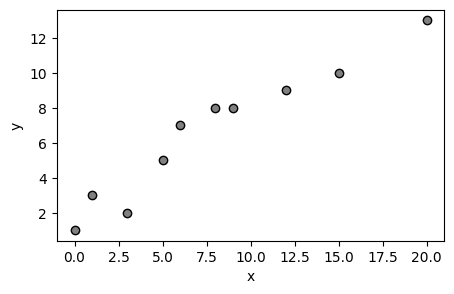

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# define os dados
x = np.array([0, 1, 3, 5, 6, 8, 9, 12, 15, 20])
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 13])

# mostra os dados
plt.figure(figsize=(5,3))
plt.plot(x, y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
plt.xlabel('x', fontsize = 10)
plt.ylabel('y', fontsize = 10)
plt.show(True)

A seguir, implementamos uma função para calcular os coeficientes.

Estimando os coeficiente através do método dos mínimos quadrados, obtemos:
    \begin{cases}
    \hat{\beta}_1=\frac{\sum_{i=1}^n (x_i- \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} = \frac{S_{xy}}{S_{xx}}\\
    \hat{\beta}_0= \bar{y}-\hat{\beta_1}\bar{x}
    \end{cases}

Coeficientes estimados:
Theta0: 2.033804377944029
Theta1: 0.5779994458298697


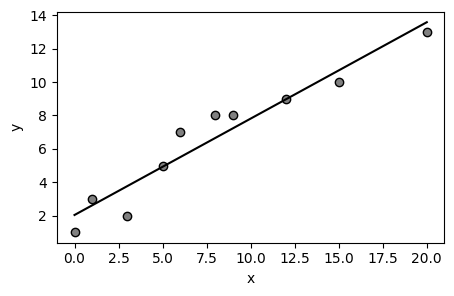

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

# função para calcular os coeficientes
def estimate_coef(x, y):
    n = np.size(x) # número de observações
    # valores médios das observações
    m_x, m_y = np.mean(x), np.mean(y)
    S_xy = 0
    S_xx = 0
    # calcula a covariância e variância
    for i in range(0, len(x)):
        S_xy = S_xy + (x[i]-m_x)*(y[i]-m_y)
        S_xx = S_xx + (x[i]-m_x)**2
    # calcula os coeficientes do modelo
    b_1 = S_xy / S_xx
    b_0 = m_y - b_1*m_x
    return(b_0, b_1)

# dados observados
x = np.array([0, 1, 3, 5, 6, 8, 9, 12, 15, 20])
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 13])

# realiza o ajuste
b = estimate_coef(x, y)
y_pred = b[0] + b[1]*x
print('Coeficientes estimados:')
print('Theta0:', b[0])
print('Theta1:', b[1])


# mostra os dados
plt.figure(figsize=(5,3))
plt.plot(x, y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra o modelo ajustado
plt.plot(x,y_pred, color='black')
plt.xlabel('x', fontsize = 10)
plt.ylabel('y', fontsize = 10)
plt.show(True)

Uma medida importante é o coeficiente R2, que mede a proporção da variabilidade em Y que pode ser explicada a partir de X.
$$
R^2 = 1 - \frac{\sum_{i=1}^n (y_i-\hat{y}_i)^2}{\sum_{i=1}^n(y_i -\bar{y})^2}
$$

In [ ]:
# calcula o coeficiente R2
def R2(y,y_hat):
    n = len(y)
    m_y = np.mean(y)
    RSS = 0; SST = 0
    for i in range(0,len(y)):
        RSS = RSS + (y[i]-y_hat[i])**2
        SST = SST + (y[i]-m_y)**2
    R2 = 1 - RSS/SST
    return R2

print('R2 = ', R2(y, y_pred))

R2 =  0.9246218128842856


O coeficiente R2 pode ser escrito como o coeficiente de Pearson ao quadrado:
$$
R^2 = \frac{S_{xy}^2}{S_{xx}S_{yy}}  = \frac{\left( \sum_{i=1}^n (x_i- \bar{x})(y_i - \bar{y})\right)^2}{\sum_{i=1}^n (x_i - \bar{x})^2\sum_{i=1}^n (y_i - \bar{y})^2}
$$

In [ ]:
import numpy as np

def R2(x,y):
    n = len(x)
    m_x, m_y = np.mean(x), np.mean(y)
    S_xy = 0
    S_xx = 0
    S_yy = 0
    for i in range(0, len(x)):
        S_xy = S_xy + (x[i]-m_x)*(y[i]-m_y)
        S_xx = S_xx + (x[i]-m_x)**2
        S_yy = S_yy + (y[i]-m_y)**2
    R2 = (S_xy**2)/(S_xx*S_yy)
    return R2


x = np.array([0, 1, 3, 5, 6, 8, 9, 12, 15, 20])
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 13])
print('R2 = ', R2(x,y))

R2 =  0.9246218128842854


Quanto mais próximo de um, melhor é o ajuste da regressão linear.

Podemos ainda usar a biblioteca sciklearn:

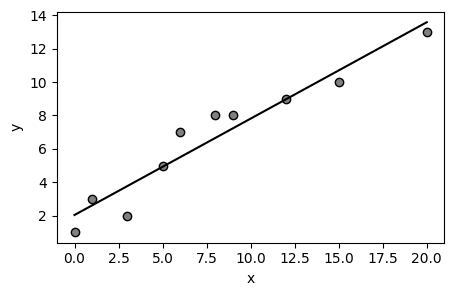

Estimated coefficients:
b_0 = 2.033804377944029  
b_1 = 0.5779994458298697


In [ ]:
from sklearn.linear_model import LinearRegression

x = x.reshape(-1, 1)
reg = LinearRegression().fit(x, y)
y_pred = reg.predict(x)

# mostra o modelo ajustado
plt.figure(figsize=(5,3))
plt.plot(x, y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
plt.plot(x,y_pred, color='black')
plt.xlabel('x', fontsize = 10)
plt.ylabel('y', fontsize = 10)
plt.savefig('regress.svg')
plt.show(True)

print("Estimated coefficients:\nb_0 = {}  \nb_1 = {}".format(b[0], b[1]))

Coeficiente R2:

In [ ]:
R2 = reg.score(x, y)
print('R2:', R2)

R2: 0.9246218128842856


---

## Teste de hipóteses:

Utilizado para verificar se existe relação linear significativa.



**Hipóteses**

*Hipótese Nula*

$$
H_0 : \theta_1 = 0
$$

Não existe relação linear.


*Hipótese Alternativa*

$$
H_1 : \theta_1 \neq 0
$$

Existe relação linear significativa.


**Interpretação**

Se:

```python
p-value <= 0.05
```

👉 rejeitamos $H_0$

Isso indica evidência estatística de relação linear.

No caso do modelo de regressão linear simples:

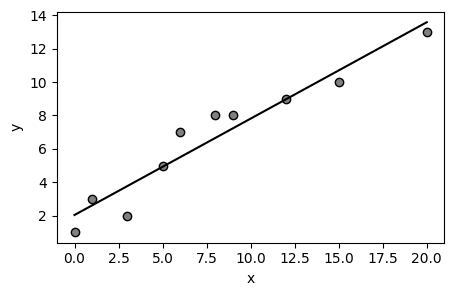

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.925
Model:                            OLS   Adj. R-squared:                  0.915
Method:                 Least Squares   F-statistic:                     98.13
Date:                Wed, 15 Jan 2025   Prob (F-statistic):           9.11e-06
Time:                        15:33:37   Log-Likelihood:                -14.103
No. Observations:                  10   AIC:                             32.21
Df Residuals:                       8   BIC:                             32.81
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0338      0.579      3.512      0.0

/usr/local/lib/python3.10/dist-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=10
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
np.random.seed(42)

# dados
x = np.array([0, 1, 3, 5, 6, 8, 9, 12, 15, 20])
y = np.array([1, 3, 2, 5, 7, 8, 8, 9, 10, 13])

# cria a matrix X
X = np.transpose([np.ones(len(x)),x])
# ajusta o modelo
model = sm.OLS(y, X)
model_adjusted = model.fit()
y_pred = model_adjusted.predict(X)

# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(x, y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
plt.plot(x,y_pred, color='black')
plt.xlabel('x', fontsize = 10)
plt.ylabel('y', fontsize = 10)
plt.savefig('linear-regress-OLS.svg')
plt.show(True)

# mostra os resultados do modelo
print(model_adjusted.summary())

In [ ]:
print('IC: ', model_adjusted.conf_int(alpha=0.05))

IC:  [[0.69843503 3.36917372]
 [0.44344957 0.71254932]]


Vamos considerar um caso em que o modelo não se aplica, ou seja, x e y são gerados de forma independente.

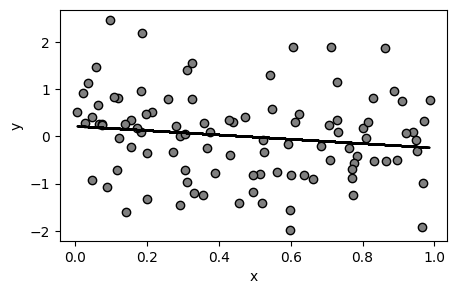

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     2.250
Date:                Wed, 15 Jan 2025   Prob (F-statistic):              0.137
Time:                        13:03:26   Log-Likelihood:                -131.15
No. Observations:                 100   AIC:                             266.3
Df Residuals:                      98   BIC:                             271.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2151      0.170      1.263      0.2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
np.random.seed(42)

# dados
n = 100
x = np.random.uniform(0, 1,n)
y = np.random.normal(0,1, n)

# cria a matrix X
X = np.transpose([np.ones(len(x)),x])
# ajusta o modelo
model = sm.OLS(y, X)
model_adjusted = model.fit()
y_pred = model_adjusted.predict(X)

# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(x, y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
plt.plot(x,y_pred, color='black')
plt.xlabel('x', fontsize = 10)
plt.ylabel('y', fontsize = 10)
plt.show(True)

# mostra os resultados do modelo
print(model_adjusted.summary())

with open('summary.txt', 'w') as fh:
    fh.write(model_adjusted.summary().as_text())

Podemos ainda usar a bibliteoca scikit learn:

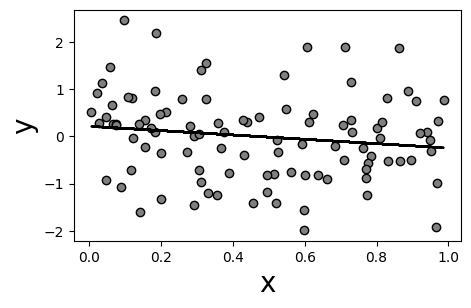

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     2.250
Date:                Wed, 15 Jan 2025   Prob (F-statistic):              0.137
Time:                        13:03:28   Log-Likelihood:                -131.15
No. Observations:                 100   AIC:                             266.3
Df Residuals:                      98   BIC:                             271.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2151      0.170      1.263      0.2

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from statsmodels.formula.api import ols
np.random.seed(42)

# dados
n = 100
x = np.random.uniform(0, 1,n)
y = np.random.normal(0,1, n)
data = pd.DataFrame({'x': x, 'y': y})

# ajusta o modelo de regressão linear
x = x.reshape(-1, 1)
reg = LinearRegression().fit(x, y)
y_predicted = reg.predict(x)

# Mostra os resultados
# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(x, y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
plt.plot(x,y_pred, color='black')
plt.xlabel('x', fontsize = 20)
plt.ylabel('y', fontsize = 20)
plt.savefig('regress-random.svg')
plt.show(True)

# sumários estatístico com OLS
model = ols("y ~ x", data).fit()
print(model.summary())

Conforme observamos, rejeitamos a hipótese nula e tanto $\beta_0$ como $\beta_1$ são nulos.

---

## Regressão linear múltipla

- existem múltiplas variáveis preditoras
- mas apenas uma saída (`Y`)

Exemplo:

```python
Preço de casa ~ área + quartos + localização
```



O modelo de regressão linear multivariado é definido por:<br>
$$
Y_j=\beta_0 + \beta_1 X_{1j} + \beta_2 X_{2j} + \beta_3 X_{3j}+\beta_4 X_{4j} + \epsilon_j.
$$
onde:
- $Y_j$: variável resposta (dependente),
-  $\beta_i$: parâmetros desconhecidos,
-  $X_{ij}$: variáveis explicativas (covariáveis, variáveis independentes),
-  $\epsilon_j$: erro aleatório.

Nesse modelo, temos as seguintes suposições:
-  $E(\epsilon_j)=0$ para $ j=1,\ldots,n$,
-  $Var(\epsilon_j) = \sigma^2$ para $ j=1,\ldots,n$,
-  $Cov(\epsilon_i,\epsilon_j)=0$ para $ i,j=1,\ldots,n$ e $i\neq j$.

Na forma matricial:

$$Y=\left[\begin{array}{c}Y_1\\ Y_2\\ \vdots \\ Y_n\end{array}\right], \
X = \left[\begin{array}{cccc}
1 & X_{11} & \ldots & X_{1k} \\
1 & X_{21} & \ldots & X_{2k} \\
\vdots & \vdots & \ddots & \vdots\\
1 & X_{n1} & \ldots & X_{np} \\
\end{array}\right], \beta = \left[\begin{array}{c}\beta_0\\ \beta_1\\\vdots \\ \beta_p\end{array}\right], \  \epsilon = \left[\begin{array}{c}\epsilon_1\\ \epsilon_2\\\vdots \\ \epsilon_n\end{array}\right]
$$  

ou seja,

$$Y_{n\times 1} = X_{n\times (p+1)} \beta_{(p+ 1)\times 1} + \epsilon_{n\times 1}. $$


A estimação dos coeficientes usando o método dos mínimos quadrados ou estimação por máxima verossimilhança:
$$
\beta = (\text{X}^T \text{X})^{-1} \text{X}^T \text{y}
$$

theta 0 : [6.77043186]
theta 1 : [1.54912282]
theta 2 : [3.02462592]


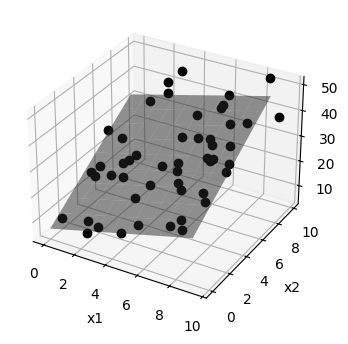

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(10)

# gera os dados
n = 50 # número de observações
x0 = np.ones((n, 1))
x1 = np.random.uniform(0,10, (n, 1))
x2 = np.random.uniform(0,10, (n, 1))
e = np.random.normal(0,5, (n, 1))
y = 4 + 2*x1 + 3*x2 + e
# combinando as características em uma matriz [n x 3]
X = np.hstack((x0, x1, x2))

# calcula os thetas usando equação normal
theta = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y)
for i in range(0,len(theta)):
    print('theta',i,':',theta[i])

# calcula o plano ajustado
k = 10
p1, p2 = np.mgrid[:k, :k]
P = np.hstack(( np.reshape(p1, (k*k, 1)),
               np.reshape(p2, (k*k, 1))))
P = np.hstack(( np.ones((k*k, 1)), P))
plane = np.reshape(np.dot(P, theta), (k, k));

# mostra os resultados
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(projection = '3d')
ax.plot(x1[:,0],x2[:,0],y[:,0],'ko')
ax.plot_surface(p1,p2,plane, color='gray',alpha=.5)
ax.set_xlabel('x1', fontsize = 10)
ax.set_ylabel('x2', fontsize = 10)
ax.set_zlabel('y', fontsize = 10)
plt.show()

In [ ]:
from sklearn.metrics import r2_score
y_pred = np.dot(X, theta)
R2 = r2_score(y, y_pred)
print('R2 = ', R2)

R2 =  0.7983613052123443


---

### Inferência sobre os parâmetros

Inferência sobre os Coeficientes

Podemos calcular intervalos de confiança para os coeficientes.

Intervalo de confiança para $\theta_1$

$$
IC(\theta_1;1-\alpha)=
\hat{\theta}_1
\pm
t_{\alpha/2,n-2}
\cdot
\frac{S_\epsilon}{
\sqrt{
\sum (x_i - \bar{x})^2
}}
$$


**Intuição**

O intervalo representa:

> uma faixa plausível para o verdadeiro valor do coeficiente.

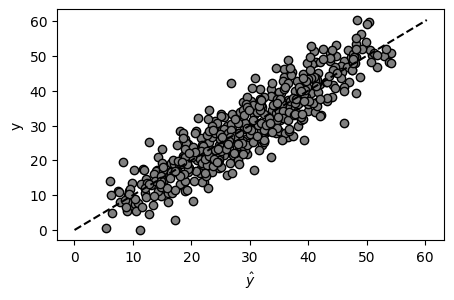

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.823
Model:                            OLS   Adj. R-squared:                  0.822
Method:                 Least Squares   F-statistic:                     767.6
Date:                Wed, 15 Jan 2025   Prob (F-statistic):          6.85e-186
Time:                        17:06:41   Log-Likelihood:                -1519.7
No. Observations:                 500   AIC:                             3047.
Df Residuals:                     496   BIC:                             3064.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.0056      0.699      5.731      0.0

In [ ]:
from statsmodels.formula.api import ols
import pandas as pd
import numpy as np
np.random.seed(42)

n = 500 # número de observações
# gera os dados
sigma = 5
x0 = np.ones((n, 1)) # x0 com entradas iguais a um
x1 = np.random.uniform(0,10, (n, 1));
x2 = np.random.uniform(0,10, (n, 1));
x3 = np.random.uniform(0,10, (n, 1));
epsilon = np.random.normal(0,sigma, (n, 1))
y = 5*x0 + 2*x1 + 3*x2 + 0*x3+ epsilon
X = np.hstack((x0,x1,x2,x3))
# ajusta o modelo
model = sm.OLS(y, X)
model_adjusted = model.fit()
y_pred = model_adjusted.predict(X)

# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(y_pred, y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
xy = np.arange(np.min(y),np.max(y),0.1)
plt.plot(xy,xy, color='black',
        linestyle='--')
plt.xlabel(r"$\hat{y}$", fontsize=10)
plt.ylabel('y', fontsize = 10)
plt.show(True)

print(model_adjusted.summary())
print('Parâmetros:\n', model_adjusted.params)

O intervalo de confiança de 95%:

In [ ]:
print('IC: ', model_adjusted.conf_int(alpha=0.10))

IC:  [[ 2.85379658  5.1573806 ]
 [ 2.00210802  2.25321685]
 [ 2.94818832  3.2106082 ]
 [-0.07305878  0.17938486]]


Após o ajuste do modelo, é importante realizar um diagnóstico com relação ao que foi assumido na sua elaboração. Quando realizamos a inferência, vimos que  assumimos que os erros são normalmente distribuídos. Desse modo, é esperando que os resíduos sejam normalmente distribuídos com média igual a zero. Verificamos essa propriedade no histograma a seguir.

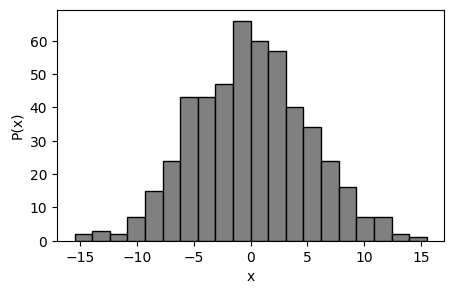

In [ ]:
residuals = model_adjusted.resid
plt.figure(figsize=(5,3))
plt.hist(residuals, bins=20, color = 'gray', histtype='bar', ec='black')
plt.xlabel('x', fontsize = 10)
plt.ylabel('P(x)',fontsize = 10)
plt.show(True)

Também podemos construir um gráfico quantil-quantil para verificar se a distribuição dos resíduos se aproxima de uma normal.

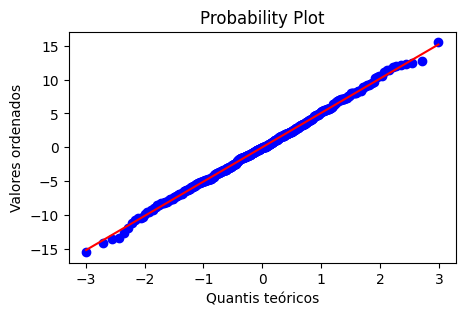

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# calcula os resíduos a partir do modelo ajustado
residuals = model_adjusted.resid
# mostra o gráfico quantil-quantil
plt.figure(figsize=(5,3))
stats.probplot(np.sort(residuals), dist="norm",plot=plt)
plt.xlabel('Quantis teóricos', fontsize = 10)
plt.ylabel('Valores ordenados',fontsize = 10)
plt.show(True)

Finalmente, podemos mostrar os resíduos em função dos valores preditos. Espera-se que os resíduos sejam aleatoriamente distribuídos em torno de zero.


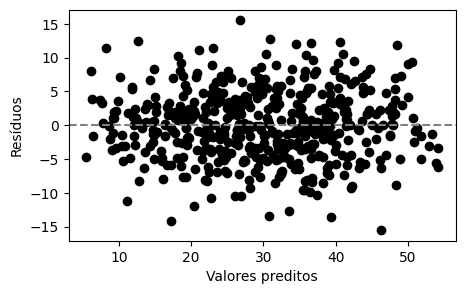

In [ ]:
plt.figure(figsize=(5,3))
plt.scatter(model_adjusted.fittedvalues, residuals,color='black')
plt.axhline(y = 0, color = 'gray', linestyle = '--')
plt.xlabel('Valores preditos',fontsize = 10)
plt.ylabel('Resíduos', fontsize = 10)
plt.show(True)

---

## Regressão polinomial

A regressão polinomial permite modelar relações não lineares.

Exemplo:

$$
y =
\theta_0 +
\theta_1 x +
\theta_2 x^2
$$

Apesar da curva ser não linear nos dados, o modelo ainda é linear nos parâmetros.


**Intuição**

A regressão polinomial:

- adiciona novas features derivadas
- transforma um problema curvo em regressão linear multivariada

Notem que o modelo não precisa ter termos lineares em X, mas apenas nos parâmetros. Por exemplo, modelo abaixo ainda é linear nos parâmetros: $$y = \beta_0 + \beta_1 x + \beta_2 x^2 + \epsilon$$

Vamos considerar um exemplo.

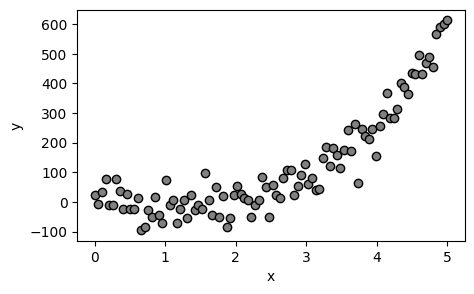

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
np.random.seed(42)

n = 100
x = np.linspace(0,5,n)
y = x**4 + np.random.normal(0,50, n)

plt.figure(figsize=(5,3))
plt.plot(x,y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
plt.ylabel("y", fontsize=10)
plt.xlabel("x", fontsize=10)

plt.show(True)

Vamos ajustar um polinômio de grau 4:
$$y = \theta_0 + \theta_1 x + \theta_2 x^2 +\theta_3 x^3 + \theta_4 x^4 + \epsilon$$

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

# define a transformação nos dados
transformer = PolynomialFeatures(degree=4, include_bias=False)
x = x.reshape((-1, 1))
transformer.fit(x)
#print('Dados originais:\n', x)

# transforma os dados incluindo uma nova coluna com valores quadráticos
Xp = transformer.transform(x)
#print('Novos dados:\n', Xp)

Vamos aplicar a regressão linear:

In [ ]:
model = LinearRegression().fit(Xp, y)
y_pred = model.predict(Xp)

Mostrando os valores preditos ($\hat{y}$) e os originais ($y$):

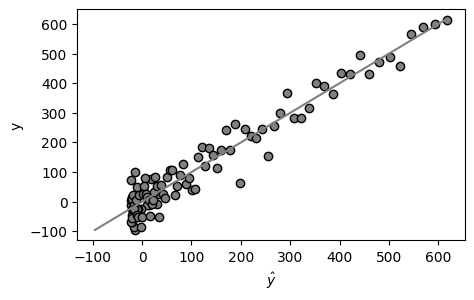

In [ ]:
import matplotlib.pyplot as plt

# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(y_pred, y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
xy = np.arange(np.min(y),np.max(y),0.1)
plt.plot(xy,xy, color='gray')
plt.xlabel(r"$\hat{y}$", fontsize=10)
plt.ylabel('y', fontsize = 10)
plt.show(True)

Mostrando os valores no gráfico original:

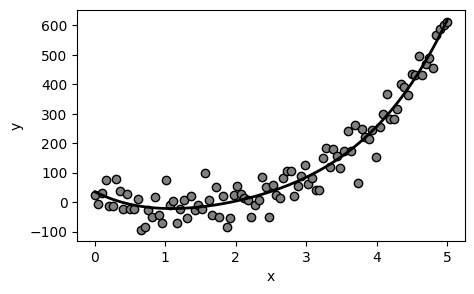

In [ ]:
import matplotlib.pyplot as plt

# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(x,y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black',
        label='Dados originais')
plt.plot(x,y_pred, 'k-',linewidth=2, label = 'Modelo ajustado')
plt.ylabel("y", fontsize=10)
plt.xlabel("x", fontsize=10)
plt.show(True)

O coeficiente R2:

In [ ]:
from sklearn.metrics import r2_score
R2 = r2_score(y, y_pred)
print('R2:', R2)

R2: 0.9393980497758725


Portanto, para ajustar um modelo com variáveis não lineares, basta gerarmos um novo conjunto de dados inserindo novas colunas aos dados originais e realizar o procedimento de regressão multivariada. Cada coluna inserida contém os dados originais elevados a uma potência definida pelos termos do modelo.

Código completo:

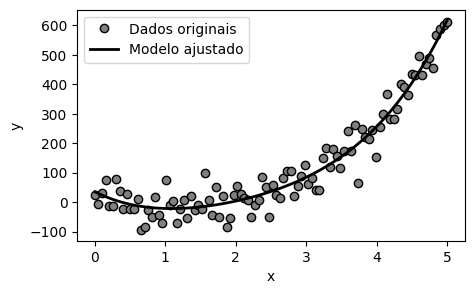

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
np.random.seed(42)

# gera os dados
n = 100
x = np.linspace(0,5,n)
y = x**4 + np.random.normal(0,50, n)

# gera os atribitos polinomiais
transformer = PolynomialFeatures(degree=4,
                                 include_bias=False)
x = x.reshape((-1, 1))
transformer.fit(x)
X = transformer.transform(x)

# aplica o modelo
model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(x,y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black',
        label='Dados originais')
plt.plot(x,y_pred, 'k-',linewidth=2,
         label = 'Modelo ajustado')
plt.ylabel("y", fontsize=10)
plt.xlabel("x", fontsize=10)
plt.legend(fontsize = 10)
plt.show(True)

Código completo usando o método OLS:

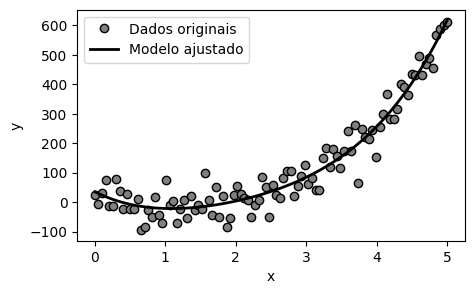

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
np.random.seed(42)

# gera os dados
n = 100
x = np.linspace(0,5,n)
y = x**4 + np.random.normal(0,50, n)
# gera os atribitos polinomiais
transformer = PolynomialFeatures(degree=4,
                                 include_bias=True)
x = x.reshape((-1, 1))
transformer.fit(x)
X = transformer.transform(x)

# ajusta o modelo
model = sm.OLS(y, X)
model_adjusted = model.fit()
y_pred = model_adjusted.predict(X)
# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(x,y, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black',
        label='Dados originais')
plt.plot(x,y_pred, 'k-',linewidth=2,
         label = 'Modelo ajustado')
plt.ylabel("y", fontsize=10)
plt.xlabel("x", fontsize=10)
plt.legend(fontsize = 10)
plt.show(True)

---

#### Relevância para Data Science

**Predição**

É a base de inúmeros modelos preditivos.

Exemplos:

- previsão de vendas
- preço de imóveis
- risco de crédito
- previsão de demanda


**Explicação de Fenômenos**

Ajuda a entender como variáveis impactam outras.

Exemplo:

```python
Renda per capita -> desempenho escolar
```


**Interpretabilidade**

Uma das grandes vantagens da regressão linear é sua interpretabilidade.

Exemplo:

```python
Um aumento de 1 unidade em X aumenta Y em θ₁ unidades
```


**Base para Machine Learning**

A regressão linear é:

- um dos modelos mais importantes da estatística
- base conceitual para diversos algoritmos de ML


#### Coeficiente de Determinação (R²)

O coeficiente de determinação mede:

> o quanto o modelo consegue explicar a variabilidade dos dados.


Fórmula

$$
R^2 =
1 -
\frac{
\sum (y_i - \hat{y}_i)^2
}{
\sum (y_i - \bar{y})^2
}
$$

*Interpretação*

| Valor de R² | Interpretação |
|---|---|
| 0 | modelo não explica os dados |
| 1 | modelo explica perfeitamente |
| 0.80 | modelo explica 80% da variabilidade |


*Importante*

Um R² alto NÃO garante:

- causalidade
- ausência de overfitting
- qualidade total do modelo

---

## Regressão linear como modelo de aprendizado supervisionado

Vamos considerar dados reais e a biblioteca scikit-learn. Inicialmente, carregamos os dados de concreto: <br>http://54.243.252.9/engr-1330-webroot/9-MyJupyterNotebooks/44-PredictingConcreteStrength/ConcreteStrength.html

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/dados/concrete_data.csv', header=(0))

print("Número de linhas e colunas:", data.shape)
data.head(10)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Número de linhas e colunas: (1030, 9)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
5,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,28,39.29


Selecionamos os conjuntos de teste e treinamento, sendo que $p$% dos dados serão usados como teste e (1-p)%, como treinamento.

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np
np.random.seed(42)

# converte para o numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]
# divide o conjunto em treinamento e teste
p = 0.2 # fração de elementos no conjnto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p)

O ajuste dos coeficientes da regressão linear é feito usando apenas o conjunto de treinamento.

In [ ]:
from sklearn.linear_model import LinearRegression

# modelo de regressão linear múltipla
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

Notem que como temos várias variáveis, não é possível mostrar os resultados em mais de três dimensões. Nesse caso, uma maneira de visualizar a precisão na predição é graficar os valores reais versus as predições, como mostramos abaixo.

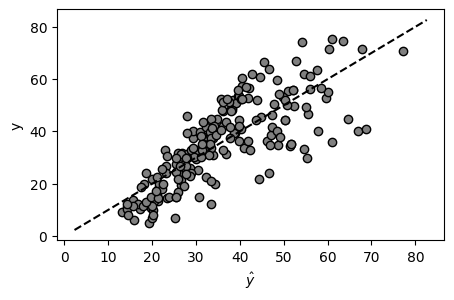

In [ ]:
import matplotlib.pyplot as plt

# faz a predição no conjunto de teste
y_pred = lm.predict(X_test)
# mostra os resultados
plt.figure(figsize=(5,3))
l = plt.plot(y_pred, y_test, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y),max(y)],[min(y),max(y)],
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=10)
plt.xlabel(r"$\hat{y}$", fontsize=10)
plt.show(True)

Quanto mais próximo da reta em vermelho, melhor será a predição, pois essa reta representa o caso em que $\hat{y} = y$.

Para quantificarmos o ajuste, calculamos o coeficiente R2.

In [ ]:
from sklearn.metrics import r2_score
R2 = r2_score(y_test, y_pred)
print('R2 = ', R2)

R2 =  0.6275531792314851


Usando a biblioteca OLS:

In [ ]:
import statsmodels.api as sm

model = sm.OLS(y_train,X_train)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.929
Model:                            OLS   Adj. R-squared (uncentered):              0.929
Method:                 Least Squares   F-statistic:                              1344.
Date:                Wed, 15 Jan 2025   Prob (F-statistic):                        0.00
Time:                        13:11:30   Log-Likelihood:                         -3108.7
No. Observations:                 824   AIC:                                      6233.
Df Residuals:                     816   BIC:                                      6271.
Df Model:                           8                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

Fazendo a predição no conjunto de teste:

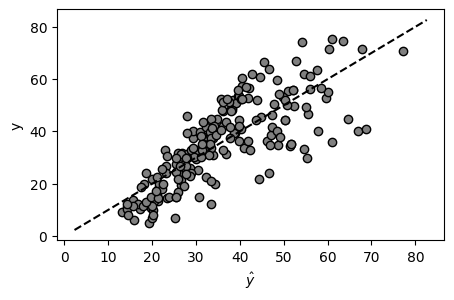

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

yhat = results.predict(X_test)

# mostra os resultados
plt.figure(figsize=(5,3))
l = plt.plot(y_pred, y_test, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y),max(y)],[min(y),max(y)],
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=10)
plt.xlabel(r"$\hat{y}$", fontsize=10)
plt.show(True)

Código completo:

R2: 0.6137200159111367


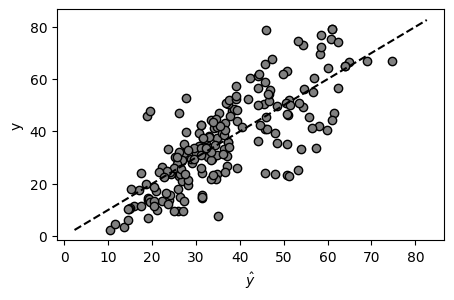

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import requests

# Faz a leitura dos dados da web
remote_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls'
response = requests.get(remote_url)
output = open('concreteData.xls', 'wb') # Abre o arquivo para escribta
output.write(response.content) # Escreve o conteúdo em um arquivo local
output.close() # fecha a conexão
# lê os dados do arquivo local
data = pd.read_excel("concreteData.xls")
# converte para o numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# divide o conjunto em treinamento e teste
p = 0.2 # fração de elementos no conjnto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p)

# modelo de regressão linear múltipla
lm = LinearRegression()
lm.fit(X_train, y_train)

# faz a predição no conjunto de teste
y_pred = lm.predict(X_test)
# calcula o coeficiente R2
R2 = r2_score(y_test, y_pred)
print('R2:', R2)

# mostra os resultados
plt.figure(figsize=(5,3))
l = plt.plot(y_pred, y_test, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y),max(y)],[min(y),max(y)],
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=10)
plt.xlabel(r"$\hat{y}$", fontsize=10)
plt.show(True)

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
R2: 0.6275531792314851


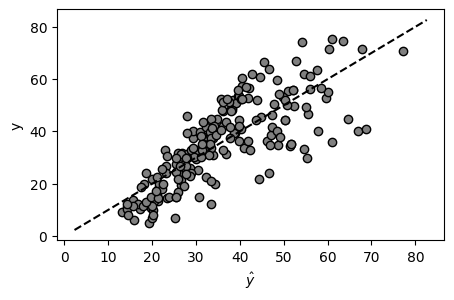

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
np.random.seed(42)

from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/dados/concrete_data.csv', header=(0))


# converte para o numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# divide o conjunto em treinamento e teste
p = 0.2 # fração de elementos no conjnto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p)

# treina o model de regressão
lm = LinearRegression()
lm.fit(X_train, y_train)

# faz a predição no conjunto de teste
y_pred = lm.predict(X_test)

# calcula o coeficiente R2
R2 = r2_score(y_test, y_pred)
print('R2:', R2)

# mostra os resultados
plt.figure(figsize=(5,3))
l = plt.plot(y_pred, y_test, 'o', color='gray', markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y),max(y)],[min(y),max(y)],
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=10)
plt.xlabel(r"$\hat{y}$", fontsize=10)
plt.show(True)

## Exercícios

1 - Considere os dados gerados com o código a seguir. Ajuste um modelo de regressão linear aos dados.

In [ ]:
import numpy as np
np.random.seed(42)
n = 100
X = 2 * np.random.rand(n, 1)
y = 4 + 3 * X + np.random.randn(n, 1)

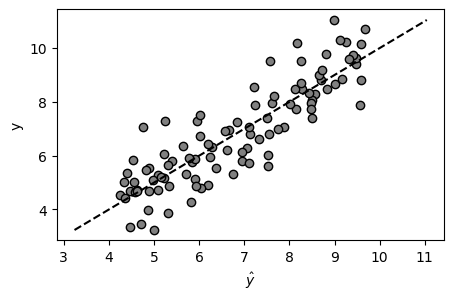

In [ ]:
# Importando as bibliotecas necessárias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
np.random.seed(42)

n = 100
X = 2 * np.random.rand(n, 1)
y = 4 + 3 * X + np.random.randn(n, 1)
X = X.reshape(-1, 1)

# modelo de regressão
model = LinearRegression()
# treina o modelo
model.fit(X, y)
# faz previsões
y_pred = model.predict(X)

# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(y_pred, y, 'o', color='gray',
         markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y),max(y)],[min(y),max(y)],
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=10)
plt.xlabel(r"$\hat{y}$", fontsize=10)
plt.show(True)

2 - Considere um conjunto de dados gerados de acordo com uma função seno com um ruído aditivo com distribuição normal com desvio padrão $\sigma = 0,5$. Ajuste um polinômio de grau três aos dados.

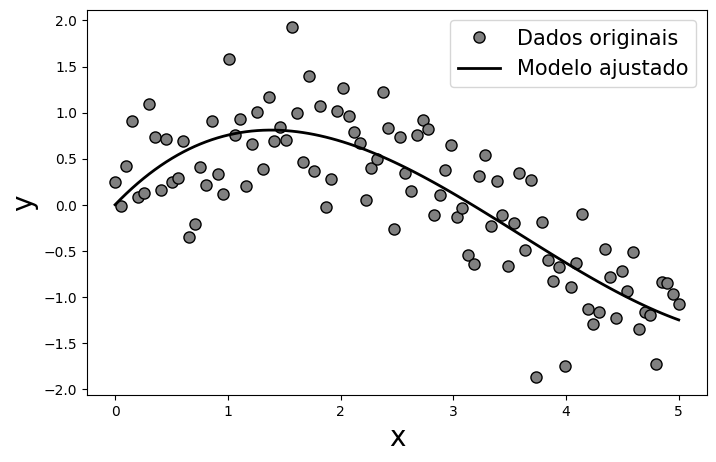

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import PolynomialFeatures
import statsmodels.api as sm
np.random.seed(42)

# gera os dados
n = 100
x = np.linspace(0,5,n)
sigma = 0.5
y = np.sin(x) + np.random.normal(0,sigma, n)
# gera os atribitos polinomiais
transformer = PolynomialFeatures(degree=3,
                                 include_bias=False)
x = x.reshape((-1, 1))
transformer.fit(x)
X = transformer.transform(x)

# ajusta o modelo
model = sm.OLS(y, X)
model_adjusted = model.fit()
# faz a predição
y_pred = model_adjusted.predict(X)

# ajusta o modelo
model = sm.OLS(y, X)
model_adjusted = model.fit()
y_pred = model_adjusted.predict(X)
# mostra os resultados
plt.figure(figsize=(8,5))
plt.plot(x,y, 'o', color='gray', markersize=8,
         markerfacecolor='gray',
         markeredgecolor='black',
        label='Dados originais')
plt.plot(x,y_pred, 'k-',linewidth=2,
         label = 'Modelo ajustado')
plt.ylabel("y", fontsize=20)
plt.xlabel("x", fontsize=20)
plt.legend(fontsize = 15)
plt.savefig('regress-ex2.svg')
plt.show(True)

3 - O conjunto obtido de testes aerodinâmicos e acústicos realizados pela NASA (\emph{National Aeronautics and Space Administration}), possui 1503 amostras com cinco variáveis de entrada: frequência (hertz), ângulo (grau), comprimento da corda (metro), velocidade do fluxo livre (metros por segundo), espessura do deslocamento lateral da sucção (metro).  Considerando essa variáveis, construa um modelo de regressão para predizer  o nível de pressão sonora. Os dados estão no link: https://archive.ics.uci.edu/ml/datasets/Airfoil+Self-Noise

In [ ]:
import pandas as pd
import urllib

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat'
data = pd.read_csv(url, sep='\s+', header = None)
data.columns = ['freq','angle','comp','vel','suc', 'pres']
data.head(10)

,freq,angle,comp,vel,suc,pres
0,800,0.0,0.3048,71.3,0.002663,126.201
1,1000,0.0,0.3048,71.3,0.002663,125.201
2,1250,0.0,0.3048,71.3,0.002663,125.951
3,1600,0.0,0.3048,71.3,0.002663,127.591
4,2000,0.0,0.3048,71.3,0.002663,127.461
5,2500,0.0,0.3048,71.3,0.002663,125.571
6,3150,0.0,0.3048,71.3,0.002663,125.201
7,4000,0.0,0.3048,71.3,0.002663,123.061
8,5000,0.0,0.3048,71.3,0.002663,121.301
9,6300,0.0,0.3048,71.3,0.002663,119.541


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
np.random.seed(42)

# converte para o formato Numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# divide o conjunto em treinamento e teste
p = 0.2 # fracao e elementos no conjnto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p)

In [ ]:
from sklearn.linear_model import LinearRegression

# modelo de regressão linear múltipla
lm = LinearRegression()
lm.fit(X_train, y_train)

LinearRegression()

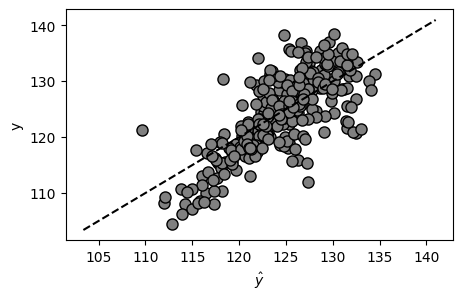

In [ ]:
import matplotlib.pyplot as plt

# faz a predicao no conjunto de teste
y_pred = lm.predict(X_test)

# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(y_pred, y_test, 'o', color='gray',
         markersize=8,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y),max(y)],[min(y),max(y)],
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=10)
plt.xlabel(r"$\hat{y}$", fontsize=10)
plt.show(True)

In [ ]:
from sklearn.metrics import r2_score
R2 = r2_score(y_test, y_pred)
print('R2:', R2)

R2: 0.5582979754897284


4 - Considere os dados da Nasa novamente. Remova as variáveis não significativas e ajuste o modelo de regressão linear.

In [ ]:
import pandas as pd
import urllib
import numpy as np
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

np.random.seed(42)

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00291/airfoil_self_noise.dat'
data = pd.read_csv(url, sep='\s+', header = None)
data.columns = ['freq','angle','comp','vel','suc', 'pres']

# converte para o formato Numpy
data = data.to_numpy()
nrow,ncol = data.shape
y = data[:,-1]
X = data[:,0:ncol-1]

# divide o conjunto em treinamento e teste
p = 0.2 # fracao e elementos no conjnto de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = p)


model = sm.OLS(y_train,X_train)
results = model.fit()
print(results.summary())

                                 OLS Regression Results                                
Dep. Variable:                      y   R-squared (uncentered):                   0.941
Model:                            OLS   Adj. R-squared (uncentered):              0.941
Method:                 Least Squares   F-statistic:                              3852.
Date:                Wed, 15 Jan 2025   Prob (F-statistic):                        0.00
Time:                        13:13:32   Log-Likelihood:                         -5803.9
No. Observations:                1202   AIC:                                  1.162e+04
Df Residuals:                    1197   BIC:                                  1.164e+04
Df Model:                           5                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

5 - Considere os dados das casas de concreto. Remova as variáveis não significativas e ajuste o modelo de regressão linear.

Vamos ler os dados e realizar a inferência no conjunto de treinamento.

In [ ]:
import pandas as pd
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split

import requests

remote_url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls'
response = requests.get(remote_url)
output = open('Concrete_Data.xls', 'wb') # Abre o arquivo para escribta
output.write(response.content) # Escreve o conteúdo em um arquivo local
output.close() # fecha a conexão
# lê os dados do arquivo local
data = pd.read_excel("Concrete_Data.xls")
data.columns = ['component1','Blast_Furnace', 'Fly_Ash',
                'Water', 'Superplasticizer',
                'Coars_Aggregate', 'Fin_Aggregate',
                'Age', 'Concret_compressive' ]

# separa os conjuntos de treinamento e teste
train, test = train_test_split(data, test_size=0.2, random_state=42)
# define o modelo: y ~ x1 + x2 + ...
model_string =  data.columns[0]
features = data.columns[1:-1]
for s in features:
    model_string = model_string + '+' + s
model_string = data.columns[-1] + '~' + model_string
print('Modelo as ser ajustado: ', model_string)
# realiza a inferência usando o método ols
model = ols(model_string,train).fit()
print(model.summary())

Modelo as ser ajustado:  Concret_compressive~component1+Blast_Furnace+Fly_Ash+Water+Superplasticizer+Coars_Aggregate+Fin_Aggregate+Age
                             OLS Regression Results                            
Dep. Variable:     Concret_compressive   R-squared:                       0.610
Model:                             OLS   Adj. R-squared:                  0.607
Method:                  Least Squares   F-statistic:                     159.7
Date:                 Wed, 15 Jan 2025   Prob (F-statistic):          3.70e-161
Time:                         13:13:37   Log-Likelihood:                -3108.3
No. Observations:                  824   AIC:                             6235.
Df Residuals:                      815   BIC:                             6277.
Df Model:                            8                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|     

Se fizemos o download do arquivo, podemos ler direto do disco rígido.

In [ ]:
import pandas as pd
from statsmodels.formula.api import ols

from google.colab import drive
drive.mount('/content/drive/')
data = pd.read_csv('/content/drive/My Drive/dados/concrete_data.csv', header=(0))

data.columns = ['component1','Blast_Furnace', 'Fly_Ash',
                'Water', 'Superplasticizer',
                'Coars_Aggregate', 'Fin_Aggregate',
                'Age', 'Concret_compressive' ]

# separa os conjuntos de treinamento e teste
train, test = train_test_split(data, test_size=0.2, random_state=42)
# define o modelo: y ~ x1 + x2 + ...
model_string =  data.columns[0]
features = data.columns[1:-1]
for s in features:
    model_string = model_string + '+' + s
# define a fórmula do modelo
model_string = 'Concret_compressive' + '~' + model_string
print('Modelo as ser ajustado: ', model_string)
# realiza a inferência usando o método ols
model = ols(model_string,train).fit()
print(model.summary())

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Modelo as ser ajustado:  Concret_compressive~component1+Blast_Furnace+Fly_Ash+Water+Superplasticizer+Coars_Aggregate+Fin_Aggregate+Age
                             OLS Regression Results                            
Dep. Variable:     Concret_compressive   R-squared:                       0.611
Model:                             OLS   Adj. R-squared:                  0.607
Method:                  Least Squares   F-statistic:                     159.7
Date:                 Wed, 15 Jan 2025   Prob (F-statistic):          3.46e-161
Time:                         13:13:49   Log-Likelihood:                -3108.2
No. Observations:                  824   AIC:                             6234.
Df Residuals:                      815   BIC:                             6277.
Df Model:                            8                                         
Covariance Typ

Removendo as variáveis não significativas e ajusta o modelo no conjunto de treinamento, novamente.

In [ ]:
train = train.drop(['Coars_Aggregate','Fin_Aggregate'],axis=1)
test = test.drop(['Coars_Aggregate','Fin_Aggregate'],axis=1)
# define o modelo: y ~ x1 + x2 + ...
model_string =  train.columns[0]
features = train.columns[1:-1]
for s in features:
    model_string = model_string + '+' + s
model_string = data.columns[-1] + '~' + model_string
print('Modelo as ser ajustado: ', model_string)
# realiza a inferência usando o método ols
model = ols(model_string,train).fit()
print(model.summary())

Modelo as ser ajustado:  Concret_compressive~component1+Blast_Furnace+Fly_Ash+Water+Superplasticizer+Age
                             OLS Regression Results                            
Dep. Variable:     Concret_compressive   R-squared:                       0.609
Model:                             OLS   Adj. R-squared:                  0.606
Method:                  Least Squares   F-statistic:                     211.7
Date:                 Wed, 15 Jan 2025   Prob (F-statistic):          1.27e-162
Time:                         13:13:52   Log-Likelihood:                -3110.3
No. Observations:                  824   AIC:                             6235.
Df Residuals:                      817   BIC:                             6268.
Df Model:                            6                                         
Covariance Type:             nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
----------

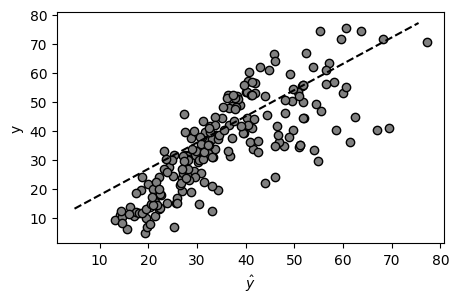

In [ ]:
predict = model.get_prediction(test).summary_frame(alpha=0.05)
y_test = test['Concret_compressive']
y_pred = predict['mean']

# mostra os resultados
plt.figure(figsize=(5,3))
plt.plot(y_pred, y_test, 'o', color='gray',
         markersize=6,
         markerfacecolor='gray',
         markeredgecolor='black')
# mostra a linha x = y
plt.plot([min(y_test),max(y_test)],[min(y_pred),max(y_pred)],
         color = 'black', linestyle='--')
plt.ylabel("y", fontsize=10)
plt.xlabel(r"$\hat{y}$", fontsize=10)
plt.savefig('regression-ex5.svg')
plt.show(True)

In [ ]:
from sklearn.metrics import r2_score
R2 = r2_score(y_test, y_pred)
print('R2:', R2)

R2: 0.6288285444264674
